
# IT Ticket Triage — Notebook-first Project

Этот ноутбук — **главный файл проекта**. Здесь ты увидишь:

1. **Очень подробный EDA** (много графиков): распределения, пропуски, временные тренды, текстовые закономерности, дубли и шум разметки.
2. **Обучение модели** (train/test split по времени), метрики, confusion matrix.
3. **Explainability**: какие слова/фразы влияют на предсказание (глобально и локально).
4. **Retrieval похожих тикетов** без дублей (и почему раньше могло показывать 3 одинаковых).
5. **Policy слой** (hard rules), который спасает “критичные” кейсы вроде *«у меня украли 100к долларов»*.
6. **GPT (Transformer)**: 
   - генерирует объяснение + next steps в **строгом JSON**
   - может быть fallback, если ML не уверен (novel/out-of-domain тикеты)
7. **Сохранение артефактов** в `../artifacts/`, которые использует Streamlit `app.py`.

> ⚠️ Важно: датасет `synthetic_it_support_tickets.csv` **синтетический и сильно шаблонный** — в EDA мы это докажем.


In [119]:

# === Setup & Imports ===
import os
import re
import json
import math
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
import joblib

# Reproducibility
np.random.seed(42)

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "synthetic_it_support_tickets.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)


PROJECT_ROOT: /Users/artemkim/Downloads/it_ticket_triage_project_v3
DATA_PATH: /Users/artemkim/Downloads/it_ticket_triage_project_v3/data/synthetic_it_support_tickets.csv
ARTIFACTS_DIR: /Users/artemkim/Downloads/it_ticket_triage_project_v3/artifacts


In [120]:

# === Load dataset ===
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(5))


Shape: (100000, 20)


,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN


In [121]:

# === Basic schema ===
display(df.dtypes)
display(df.describe(include='all').T.head(25))


ticket_id                 object
created_at                object
customer_id               object
customer_segment          object
channel                   object
product_area              object
issue_type                object
priority                  object
status                    object
sla_plan                  object
initial_message           object
agent_first_reply         object
resolution_summary        object
resolution_time_hours    float64
reopened                   int64
customer_sentiment        object
csat_score                 int64
has_attachment             int64
platform                  object
region                    object
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ticket_id,100000,100000,TCKT_000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,100000,99959,2025-10-23T07:27:06,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,100000,9999,CUST_07153,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,100000,5,small_business,20203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,100000,5,phone_transcript,20133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_area,100000,7,mobile_app,14432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issue_type,100000,8,how_to,12739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,100000,4,low,39735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,100000,5,resolved,50131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sla_plan,100000,3,standard,60066,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## 1) EDA — Missing values

Смотрим долю пропусков. Это важно для:
- выбора признаков
- понимания, что можно использовать в triage (на момент создания тикета)


,missing_rate,missing_pct
resolution_time_hours,0.39887,39.89
resolution_summary,0.39887,39.89
region,0.19997,20.00
created_at,0.00000,0.00
platform,0.00000,0.00
has_attachment,0.00000,0.00
csat_score,0.00000,0.00
customer_sentiment,0.00000,0.00
reopened,0.00000,0.00
agent_first_reply,0.00000,0.00


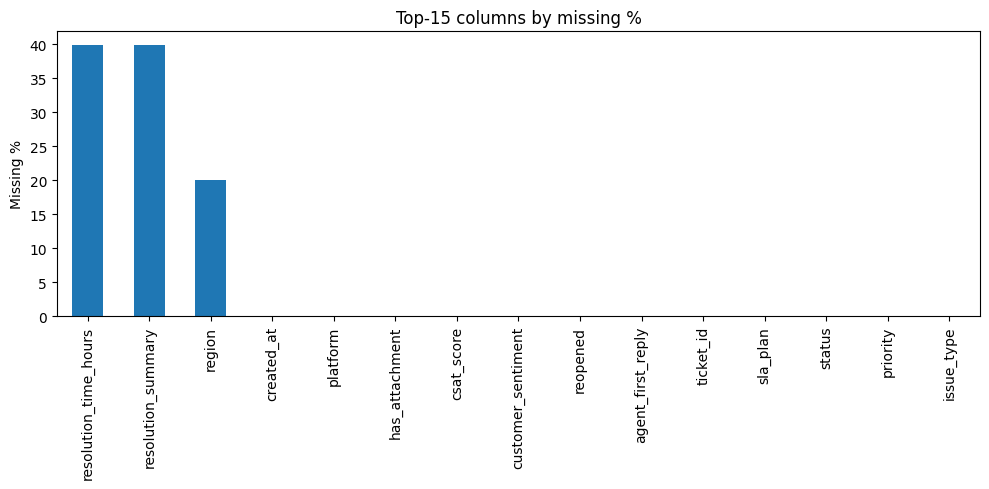

In [122]:

missing = df.isna().mean().sort_values(ascending=False)
missing_df = pd.DataFrame({"missing_rate": missing, "missing_pct": (missing*100).round(2)})
display(missing_df)

plt.figure(figsize=(10,5))
missing_df["missing_pct"].head(15).plot(kind="bar")
plt.title("Top-15 columns by missing %")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()



## 2) EDA — Время и объём

Проверим временной диапазон и динамику тикетов.


Min created_at: 2022-01-01 00:16:58
Max created_at: 2025-12-30 23:45:45


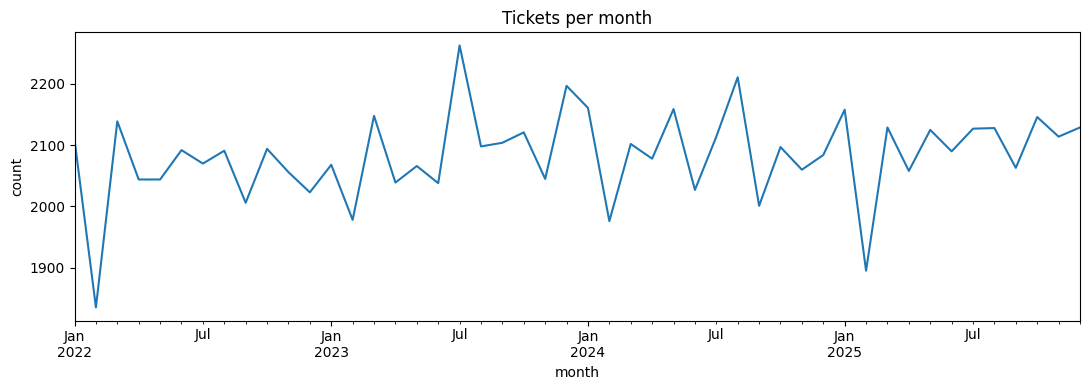

In [123]:

df["created_at_dt"] = pd.to_datetime(df["created_at"], errors="coerce")
print("Min created_at:", df["created_at_dt"].min())
print("Max created_at:", df["created_at_dt"].max())

tmp = df.dropna(subset=["created_at_dt"]).copy()
tmp["month"] = tmp["created_at_dt"].dt.to_period("M").dt.to_timestamp()

tickets_by_month = tmp.groupby("month").size()

plt.figure(figsize=(11,4))
tickets_by_month.plot(kind="line")
plt.title("Tickets per month")
plt.ylabel("count")
plt.tight_layout()
plt.show()



## 2.1) EDA — Priority во времени

Смотрим, меняется ли распределение приоритетов по месяцам.


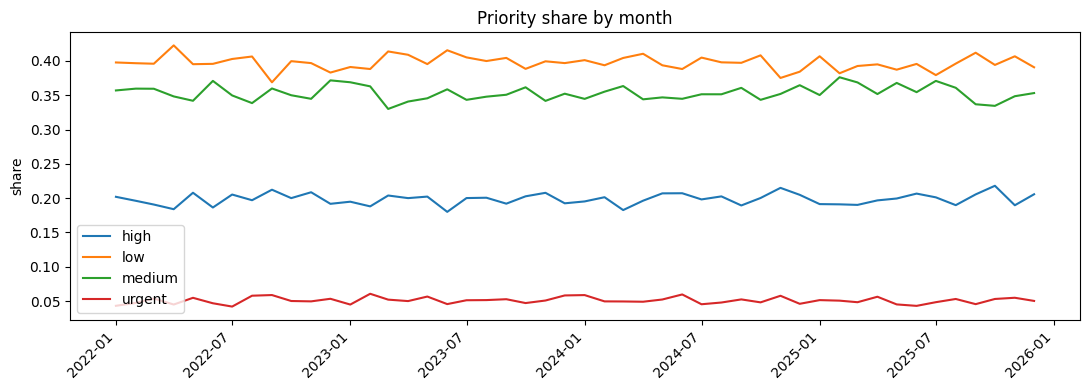

In [124]:

tmp = df.dropna(subset=["created_at_dt"]).copy()
tmp["month"] = tmp["created_at_dt"].dt.to_period("M").dt.to_timestamp()

prio_by_month = pd.crosstab(tmp["month"], tmp["priority"], normalize="index").sort_index()

plt.figure(figsize=(11,4))
for col in prio_by_month.columns:
    plt.plot(prio_by_month.index, prio_by_month[col], label=col)
plt.title("Priority share by month")
plt.ylabel("share")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()



## 2.2) EDA — Reopened / Attachments по priority

Смотрим, есть ли связь между приоритетом и:
- reopen
- наличием вложений


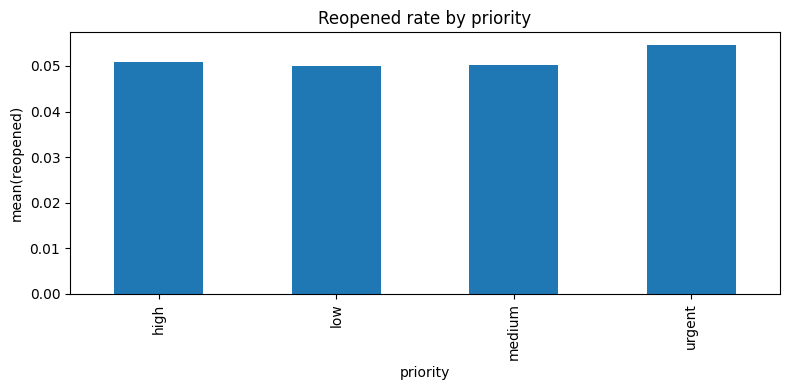

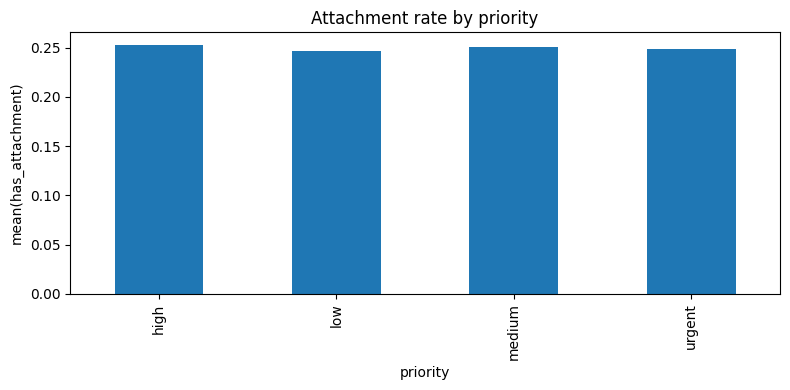

In [125]:

# Reopened rate by priority
reopen_rate = df.groupby("priority")["reopened"].mean().sort_index()
plt.figure(figsize=(8,4))
reopen_rate.plot(kind="bar")
plt.title("Reopened rate by priority")
plt.ylabel("mean(reopened)")
plt.tight_layout()
plt.show()

# Attachment rate by priority
attach_rate = df.groupby("priority")["has_attachment"].mean().sort_index()
plt.figure(figsize=(8,4))
attach_rate.plot(kind="bar")
plt.title("Attachment rate by priority")
plt.ylabel("mean(has_attachment)")
plt.tight_layout()
plt.show()



## 2.3) EDA — CSAT по priority


/var/folders/gl/96ss4btd7y5781v8lrfb_xcm0000gn/T/ipykernel_20867/423520143.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


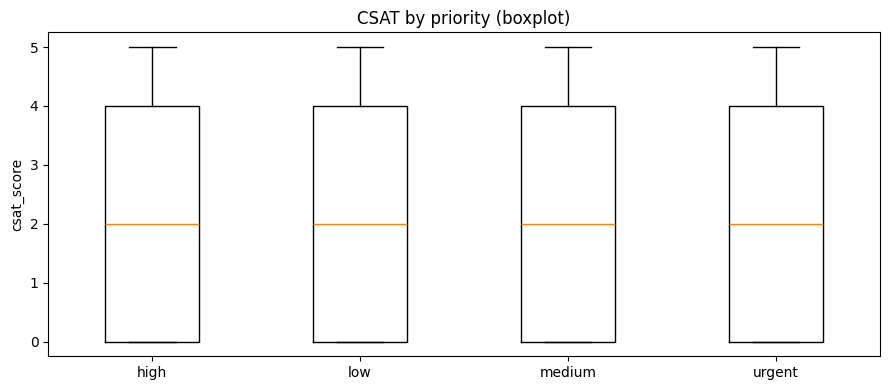

In [126]:

csat_df = df.dropna(subset=["csat_score"]).copy()
labels = sorted(df["priority"].unique())
groups = [csat_df.loc[csat_df["priority"] == p, "csat_score"].values for p in labels]
plt.figure(figsize=(9,4))
plt.boxplot(groups, labels=labels)
plt.title("CSAT by priority (boxplot)")
plt.ylabel("csat_score")
plt.tight_layout()
plt.show()



## 2.4) EDA — Region / Platform распределения и связь с priority


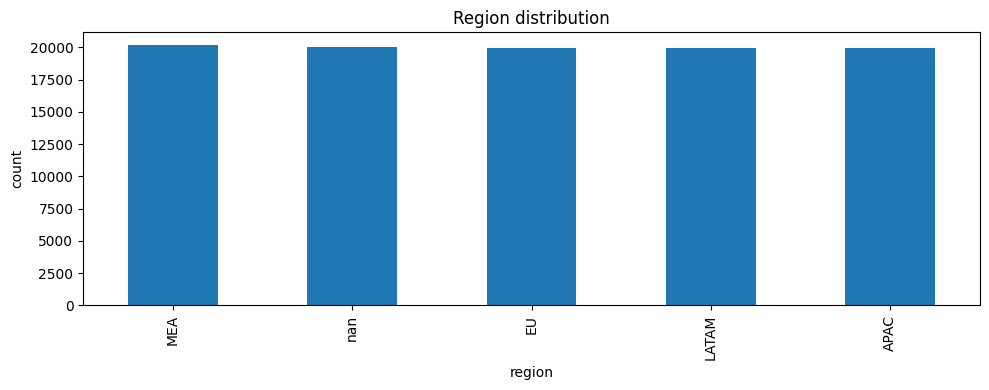

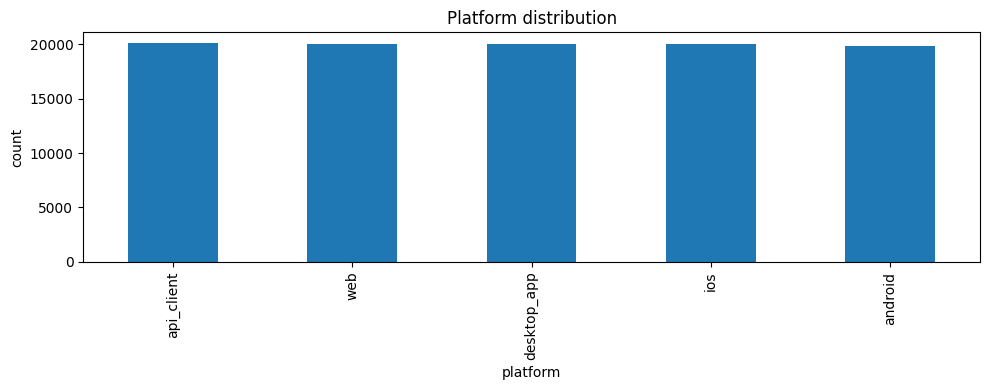

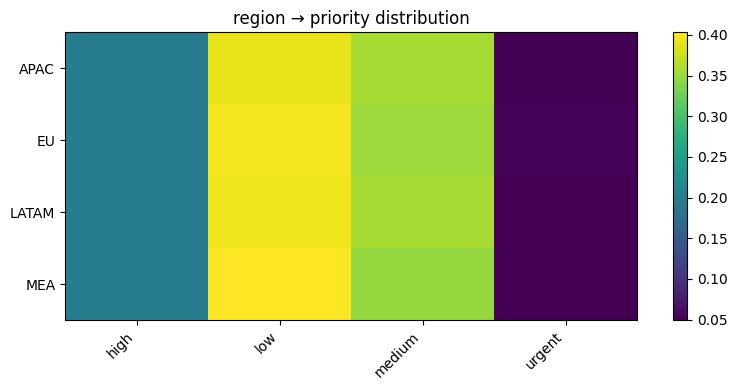

priority,high,low,medium,urgent
region,,,,
APAC,0.199,0.392,0.357,0.051
EU,0.198,0.398,0.352,0.052
LATAM,0.199,0.395,0.356,0.049
MEA,0.199,0.403,0.348,0.050


In [127]:

def _bar_plot_counts(series: pd.Series, title: str, top_n: int = 30):
    vc = series.value_counts(dropna=False).head(top_n)
    plt.figure(figsize=(10,4))
    vc.plot(kind="bar")
    plt.title(title)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# Region distribution
_bar_plot_counts(df["region"], "Region distribution")

# Platform distribution
_bar_plot_counts(df["platform"], "Platform distribution")

# Region -> priority heatmap (ignore NaN)
tab_region = pd.crosstab(df["region"], df["priority"], normalize="index")
plt.figure(figsize=(8,4))
plt.imshow(tab_region.values, aspect="auto")
plt.title("region → priority distribution")
plt.xticks(range(len(tab_region.columns)), tab_region.columns, rotation=45, ha="right")
plt.yticks(range(len(tab_region.index)), tab_region.index)
plt.colorbar()
plt.tight_layout()
plt.show()
display(tab_region.round(3))



## 3) EDA — Основные распределения (priority / issue_type / product_area / channel / segment)


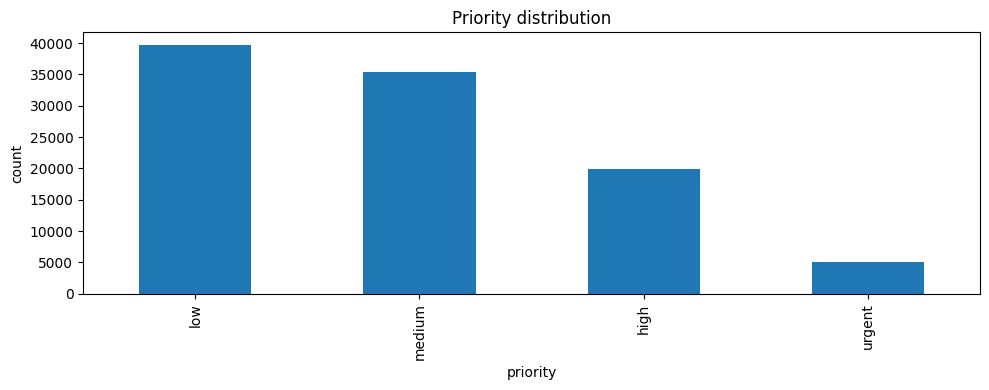

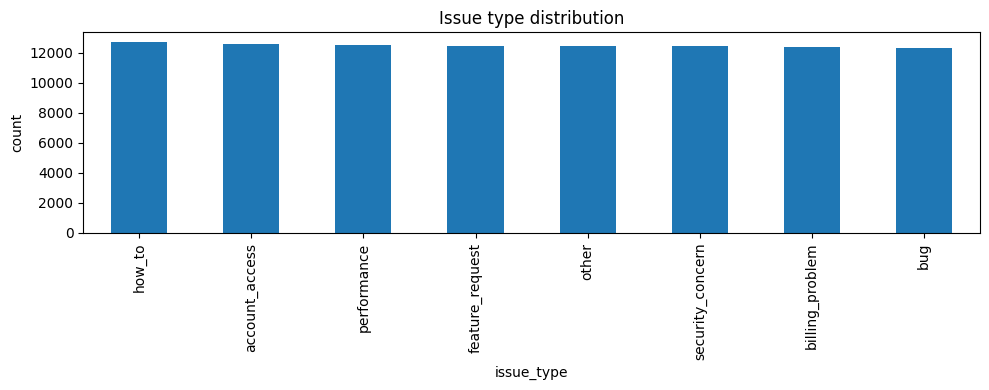

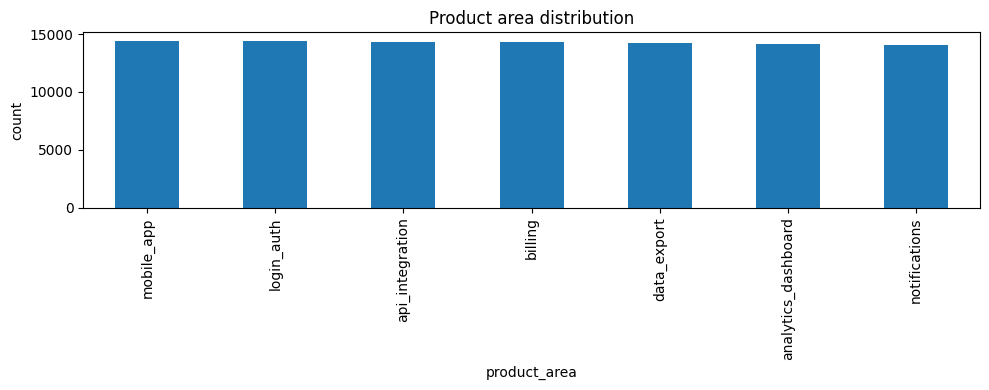

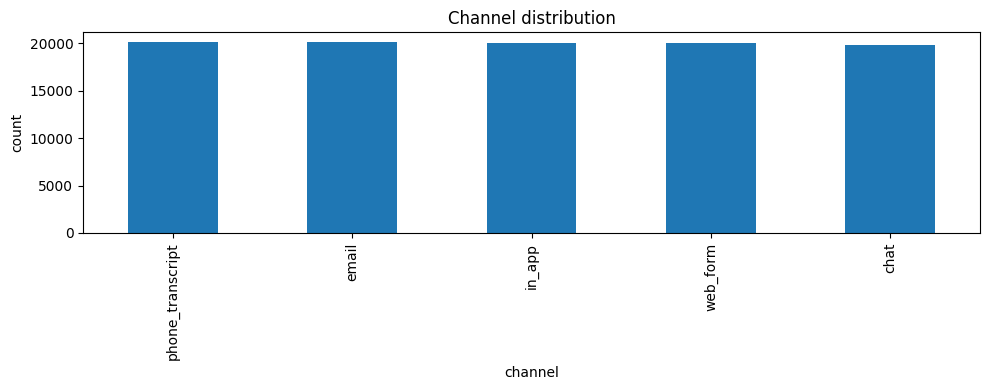

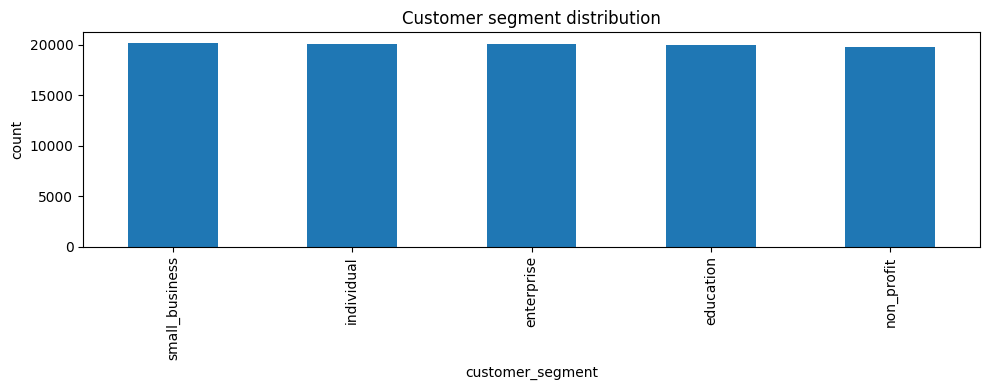

In [128]:

def bar_plot_counts(series: pd.Series, title: str, top_n: int = 30):
    vc = series.value_counts().head(top_n)
    plt.figure(figsize=(10,4))
    vc.plot(kind="bar")
    plt.title(title)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

bar_plot_counts(df["priority"], "Priority distribution")
bar_plot_counts(df["issue_type"], "Issue type distribution")
bar_plot_counts(df["product_area"], "Product area distribution")
bar_plot_counts(df["channel"], "Channel distribution")
bar_plot_counts(df["customer_segment"], "Customer segment distribution")



## 4) EDA — Crosstabs: есть ли связь с priority?


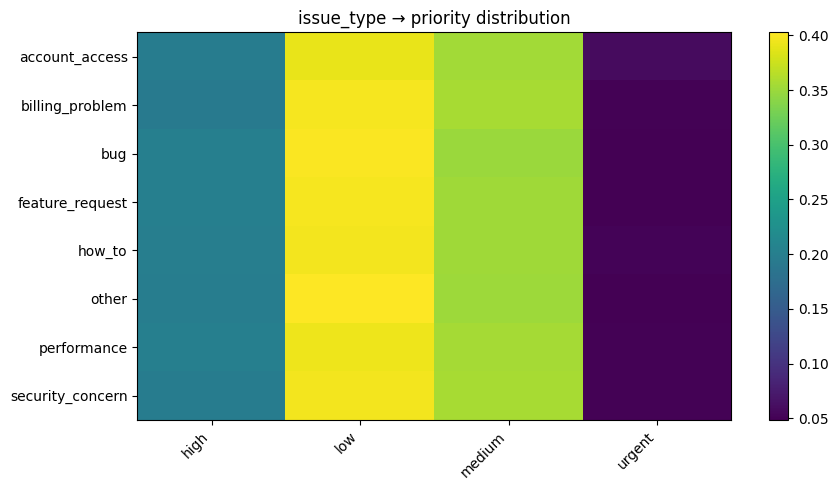

priority,high,low,medium,urgent
issue_type,,,,
account_access,0.197,0.391,0.354,0.058
billing_problem,0.195,0.398,0.356,0.051
bug,0.201,0.401,0.349,0.049
feature_request,0.201,0.398,0.352,0.049
how_to,0.199,0.397,0.352,0.051
other,0.198,0.403,0.351,0.048
performance,0.201,0.394,0.355,0.050
security_concern,0.197,0.397,0.356,0.050


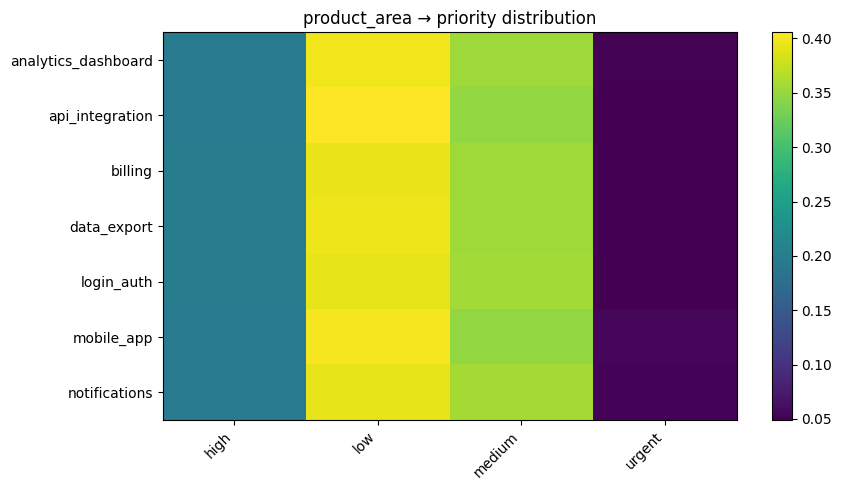

priority,high,low,medium,urgent
product_area,,,,
analytics_dashboard,0.198,0.398,0.353,0.051
api_integration,0.198,0.406,0.347,0.050
billing,0.200,0.395,0.355,0.050
data_export,0.201,0.396,0.354,0.049
login_auth,0.200,0.393,0.357,0.050
mobile_app,0.197,0.401,0.348,0.054
notifications,0.198,0.392,0.358,0.052


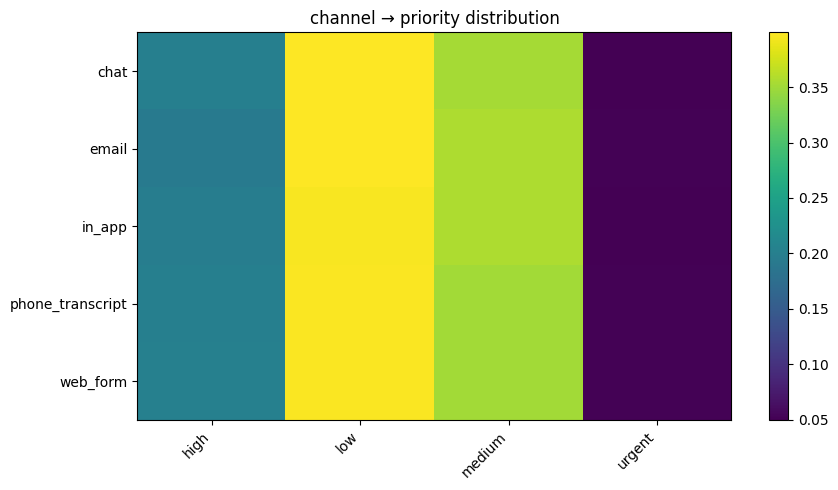

priority,high,low,medium,urgent
channel,,,,
chat,0.201,0.398,0.352,0.050
email,0.193,0.399,0.356,0.051
in_app,0.198,0.395,0.356,0.051
phone_transcript,0.201,0.397,0.351,0.052
web_form,0.201,0.397,0.351,0.051


In [129]:

def crosstab_heatmap(row_col: str, col_col: str, normalize: str = "index", title: str = ""):
    tab = pd.crosstab(df[row_col], df[col_col], normalize=normalize)
    plt.figure(figsize=(9,5))
    plt.imshow(tab.values, aspect="auto")
    plt.title(title or f"{row_col} vs {col_col} (normalize={normalize})")
    plt.xticks(range(len(tab.columns)), tab.columns, rotation=45, ha="right")
    plt.yticks(range(len(tab.index)), tab.index)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    return tab

tab_issue = crosstab_heatmap("issue_type", "priority", normalize="index", title="issue_type → priority distribution")
display(tab_issue.round(3))

tab_prod = crosstab_heatmap("product_area", "priority", normalize="index", title="product_area → priority distribution")
display(tab_prod.round(3))

tab_channel = crosstab_heatmap("channel", "priority", normalize="index", title="channel → priority distribution")
display(tab_channel.round(3))



## 5) EDA — Числовые признаки (csat_score, resolution_time_hours)

⚠️ `resolution_time_hours` и `resolution_summary` **нельзя использовать** в triage (это будущее знание),
но их можно анализировать для понимания процессов.


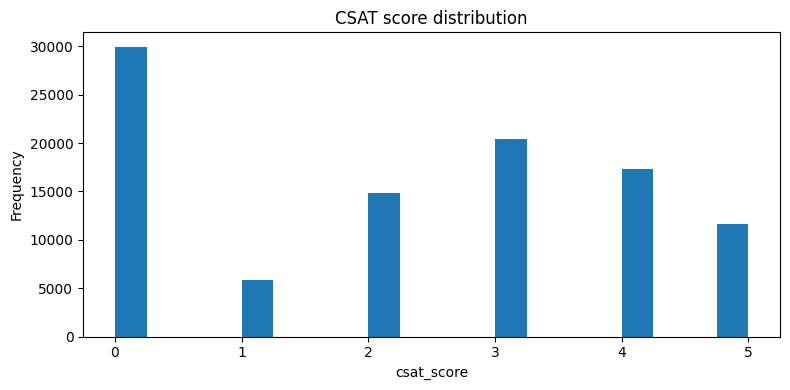

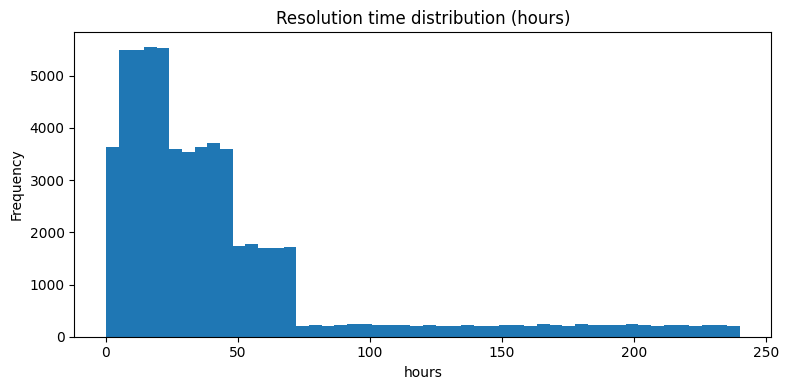

/var/folders/gl/96ss4btd7y5781v8lrfb_xcm0000gn/T/ipykernel_20867/16971851.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


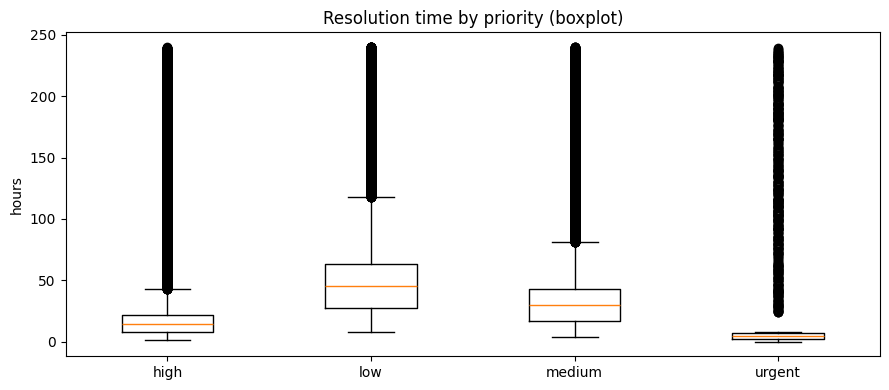

In [130]:

plt.figure(figsize=(8,4))
df["csat_score"].dropna().plot(kind="hist", bins=20)
plt.title("CSAT score distribution")
plt.xlabel("csat_score")
plt.tight_layout()
plt.show()

rt = df["resolution_time_hours"].dropna()
plt.figure(figsize=(8,4))
rt.plot(kind="hist", bins=50)
plt.title("Resolution time distribution (hours)")
plt.xlabel("hours")
plt.tight_layout()
plt.show()

rt_df = df.dropna(subset=["resolution_time_hours"]).copy()
labels = sorted(df["priority"].unique())
groups = [rt_df.loc[rt_df["priority"] == p, "resolution_time_hours"].values for p in labels]
plt.figure(figsize=(9,4))
plt.boxplot(groups, labels=labels)
plt.title("Resolution time by priority (boxplot)")
plt.ylabel("hours")
plt.tight_layout()
plt.show()



## 6) EDA — Текст: длины и базовые статистики


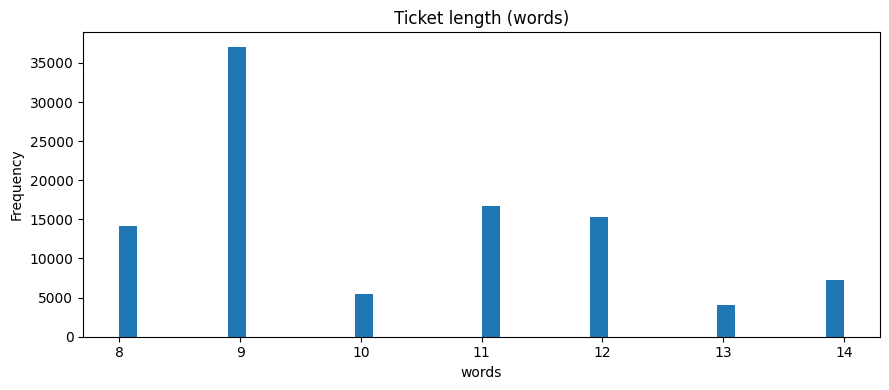

/var/folders/gl/96ss4btd7y5781v8lrfb_xcm0000gn/T/ipykernel_20867/886715233.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


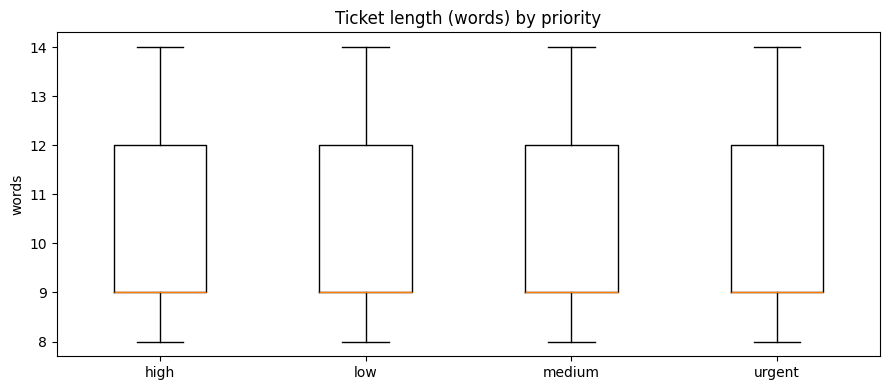

In [131]:

text = df["initial_message"].fillna("").astype(str)
df["text_len_chars"] = text.map(len)
df["text_len_words"] = text.map(lambda s: len(s.split()))

plt.figure(figsize=(9,4))
df["text_len_words"].plot(kind="hist", bins=40)
plt.title("Ticket length (words)")
plt.xlabel("words")
plt.tight_layout()
plt.show()

labels = sorted(df["priority"].unique())
groups = [df.loc[df["priority"] == p, "text_len_words"].values for p in labels]
plt.figure(figsize=(9,4))
plt.boxplot(groups, labels=labels)
plt.title("Ticket length (words) by priority")
plt.ylabel("words")
plt.tight_layout()
plt.show()



## 7) Критичный EDA: Дубли и шум разметки

Проверяем:
- сколько уникальных `initial_message`
- насколько часто один и тот же текст имеет разные `priority`


Total rows: 100000
Unique initial_message: 96
Duplication rate: 99.9040%


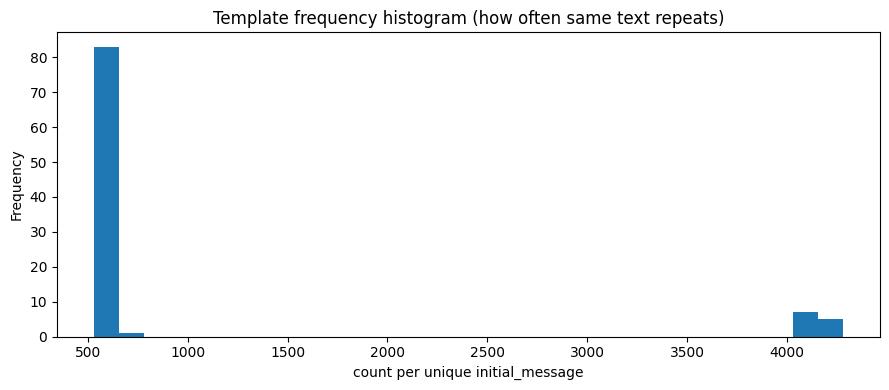

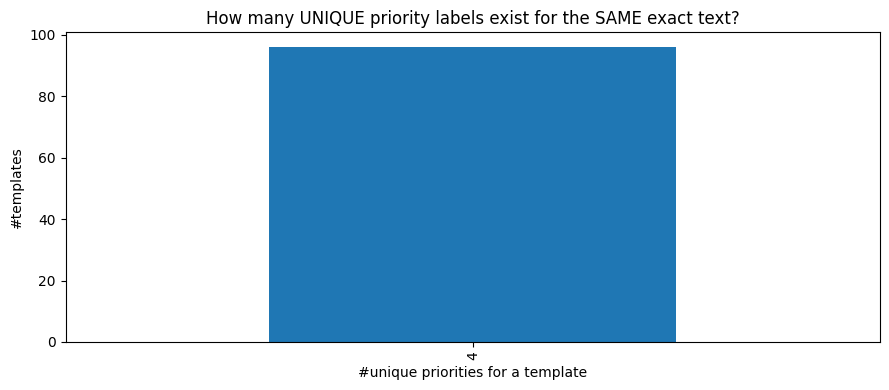

initial_message
Can you add an option to customize analytics dashboard?                     4
Can you add an option to customize api integration?                         4
The api integration page is very slow and takes a long time to load.        4
The api integration feature is not saving my changes.                       4
The analytics dashboard page is very slow and takes a long time to load.    4
The analytics dashboard feature is not saving my changes.                   4
Something seems off, can you please check my workspace?                     4
Queries in the notifications module are timing out.                         4
Queries in the mobile app module are timing out.                            4
Queries in the login auth module are timing out.                            4
Name: priority, dtype: int64


Example template: Can you add an option to customize analytics dashboard?
Priority distribution for that template:


priority
low       0.391089
medium    0.333333
high      0.221122
urgent    0.054455
Name: proportion, dtype: float64

In [132]:

unique_msgs = df["initial_message"].fillna("").nunique()
total = len(df)
print(f"Total rows: {total}")
print(f"Unique initial_message: {unique_msgs}")
print(f"Duplication rate: {1 - unique_msgs/total:.4%}")

template_counts = df["initial_message"].fillna("").value_counts()
plt.figure(figsize=(9,4))
template_counts.plot(kind="hist", bins=30)
plt.title("Template frequency histogram (how often same text repeats)")
plt.xlabel("count per unique initial_message")
plt.tight_layout()
plt.show()

prio_per_template = df.groupby(df["initial_message"].fillna(""))["priority"].nunique()
plt.figure(figsize=(9,4))
prio_per_template.value_counts().sort_index().plot(kind="bar")
plt.title("How many UNIQUE priority labels exist for the SAME exact text?")
plt.xlabel("#unique priorities for a template")
plt.ylabel("#templates")
plt.tight_layout()
plt.show()

display(prio_per_template.sort_values(ascending=False).head(10))

example_text = prio_per_template.sort_values(ascending=False).index[0]
ex = df[df["initial_message"].fillna("") == example_text]["priority"].value_counts(normalize=True)
print("\nExample template:", example_text)
print("Priority distribution for that template:")
display(ex)



## 8) Подготовка текста: PII masking

Даже если датасет синтетический, это must-have для продакшна.


In [133]:

EMAIL_RE = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
IP_RE = re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
LONG_NUM_RE = re.compile(r"\b\d{4,}\b")

def mask_pii(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text
    t = EMAIL_RE.sub("[EMAIL]", t)
    t = IP_RE.sub("[IP]", t)
    t = URL_RE.sub("[URL]", t)
    t = LONG_NUM_RE.sub("[NUMBER]", t)
    return t

df["text_masked"] = df["initial_message"].fillna("").astype(str).map(mask_pii)
display(df[["initial_message", "text_masked"]].head(5))


,initial_message,text_masked
0,I cannot log in; the system says my password i...,I cannot log in; the system says my password i...
1,I noticed a suspicious login on my account.,I noticed a suspicious login on my account.
2,The api integration feature is not saving my c...,The api integration feature is not saving my c...
3,I cannot log in; the system says my password i...,I cannot log in; the system says my password i...
4,My invoice amount is incorrect compared to the...,My invoice amount is incorrect compared to the...



## 9) Train/Test split (по времени) + baseline модели


In [134]:

df = df.sort_values("created_at_dt").reset_index(drop=True)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df["text_masked"]
y_train = train_df["priority"]
X_test = test_df["text_masked"]
y_test = test_df["priority"]

print("Train:", X_train.shape, "Test:", X_test.shape)
display(y_train.value_counts(normalize=True))


Train: (80000,) Test: (20000,)


priority
low       0.397850
medium    0.353063
high      0.197975
urgent    0.051112
Name: proportion, dtype: float64

In [135]:
vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=200_000
)

Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)

# 2) Sanity-check: vectorizer должен реально видеть текст
nnz = Xte.getnnz(axis=1)
print("NNZ test avg:", float(nnz.mean()), "min:", int(nnz.min()), "p10:", float(np.percentile(nnz, 10)))
assert nnz.mean() > 20, "Vectorizer too sparse: avg NNZ too low. Something is wrong with text preprocessing."

# 3) Models
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(Xtr, y_train)
pred_dummy = dummy.predict(Xte)

logreg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    n_jobs=-1,
    C=2.0
)
logreg.fit(Xtr, y_train)
pred_lr = logreg.predict(Xte)

sgd = SGDClassifier(
    loss="log_loss",
    alpha=1e-5,
    max_iter=4000,
    class_weight="balanced",
    random_state=42
)
sgd.fit(Xtr, y_train)
pred_sgd = sgd.predict(Xte)

def summarize(model, name, Xte, y_true, y_pred):
    out = {
        "model": name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "pred_distribution": pd.Series(y_pred).value_counts(normalize=True).to_dict(),
    }
    # confidence stats, если есть proba
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(Xte)
        out["avg_max_proba"] = float(np.mean(np.max(proba, axis=1)))
        out["p10_max_proba"] = float(np.percentile(np.max(proba, axis=1), 10))
    else:
        out["avg_max_proba"] = np.nan
        out["p10_max_proba"] = np.nan
    return out

summary = pd.DataFrame([
    summarize(dummy, "Dummy(most_frequent)", Xte, y_test, pred_dummy),
    summarize(logreg, "LogReg(char_wb 3-5, balanced)", Xte, y_test, pred_lr),
    summarize(sgd, "SGD(char_wb 3-5, balanced)", Xte, y_test, pred_sgd),
])

display(summary)

# 4) Детальный отчёт по лучшей модели (по macro_f1)
best_name = summary.sort_values("macro_f1", ascending=False).iloc[0]["model"]
best_model = {"Dummy(most_frequent)": dummy,
              "LogReg(char_wb 3-5, balanced)": logreg,
              "SGD(char_wb 3-5, balanced)": sgd}[best_name]
best_pred = {"Dummy(most_frequent)": pred_dummy,
             "LogReg(char_wb 3-5, balanced)": pred_lr,
             "SGD(char_wb 3-5, balanced)": pred_sgd}[best_name]

print("\n=== BEST MODEL:", best_name, "===")
print(classification_report(y_test, best_pred, zero_division=0))

cm = confusion_matrix(y_test, best_pred, labels=["low", "medium", "high", "urgent"])
cm_df = pd.DataFrame(cm, index=["true_low","true_medium","true_high","true_urgent"],
                        columns=["pred_low","pred_medium","pred_high","pred_urgent"])
display(cm_df)

NNZ test avg: 109.05505 min: 76 p10: 86.0


,model,accuracy,macro_f1,pred_distribution,avg_max_proba,p10_max_proba
0,Dummy(most_frequent),0.39535,0.141667,{'low': 1.0},1.000000,1.000000
1,"LogReg(char_wb 3-5, balanced)",0.20170,0.197793,"{'urgent': 0.42395, 'high': 0.2089, 'medium': ...",0.264914,0.255690
2,"SGD(char_wb 3-5, balanced)",0.31200,0.203921,"{'low': 0.63995, 'urgent': 0.20565, 'medium': ...",0.311269,0.276507



=== BEST MODEL: SGD(char_wb 3-5, balanced) ===
              precision    recall  f1-score   support

        high       0.19      0.05      0.07      4027
         low       0.40      0.64      0.49      7907
      medium       0.36      0.11      0.17      7068
      urgent       0.05      0.22      0.09       998

    accuracy                           0.31     20000
   macro avg       0.25      0.25      0.20     20000
weighted avg       0.33      0.31      0.27     20000



,pred_low,pred_medium,pred_high,pred_urgent
true_low,5073,840,395,1599
true_medium,4495,764,343,1466
true_high,2601,413,184,829
true_urgent,630,101,48,219


In [136]:

print("=== Dummy ===")
print(classification_report(y_test, pred_dummy))

print("\n=== LogReg ===")
print(classification_report(y_test, pred_lr))

print("\n=== SGD ===")
print(classification_report(y_test, pred_sgd))


=== Dummy ===
              precision    recall  f1-score   support

        high       0.00      0.00      0.00      4027
         low       0.40      1.00      0.57      7907
      medium       0.00      0.00      0.00      7068
      urgent       0.00      0.00      0.00       998

    accuracy                           0.40     20000
   macro avg       0.10      0.25      0.14     20000
weighted avg       0.16      0.40      0.22     20000


=== LogReg ===
              precision    recall  f1-score   support

        high       0.20      0.21      0.21      4027
         low       0.40      0.17      0.24      7907
      medium       0.35      0.20      0.26      7068
      urgent       0.05      0.42      0.09       998

    accuracy                           0.20     20000
   macro avg       0.25      0.25      0.20     20000
weighted avg       0.33      0.20      0.23     20000


=== SGD ===


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        high       0.19      0.05      0.07      4027
         low       0.40      0.64      0.49      7907
      medium       0.36      0.11      0.17      7068
      urgent       0.05      0.22      0.09       998

    accuracy                           0.31     20000
   macro avg       0.25      0.25      0.20     20000
weighted avg       0.33      0.31      0.27     20000



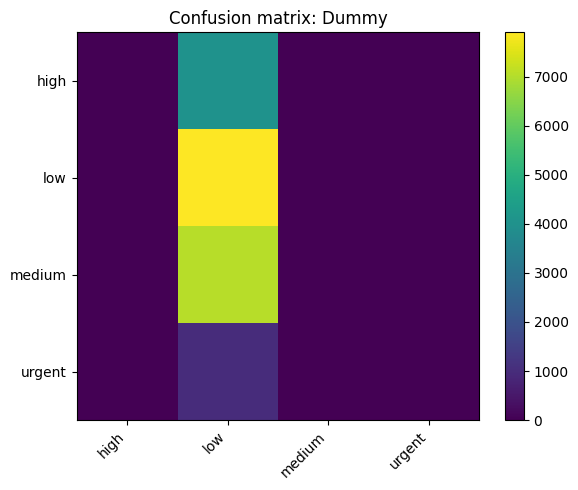

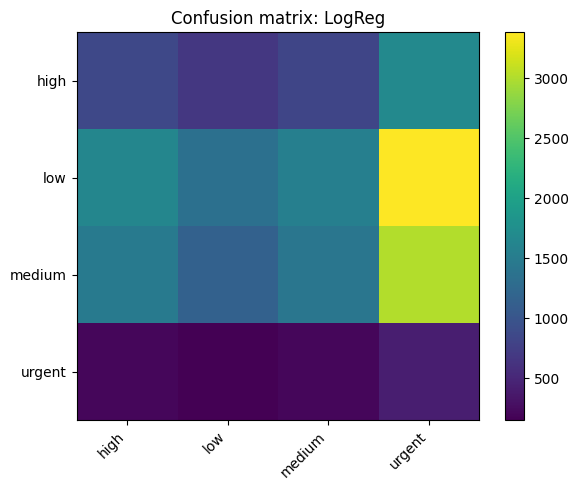

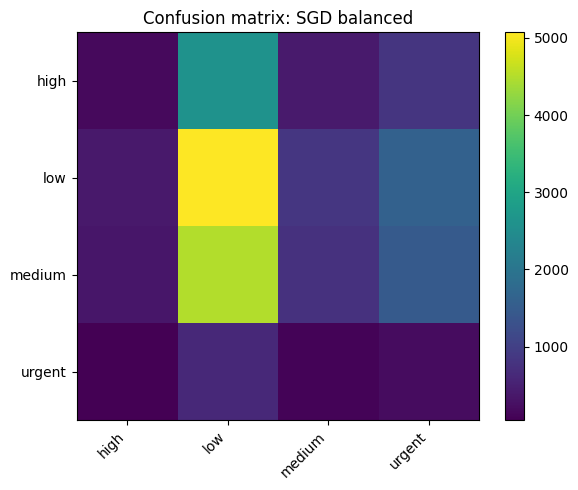

array([[ 184, 2601,  413,  829],
       [ 395, 5073,  840, 1599],
       [ 343, 4495,  764, 1466],
       [  48,  630,  101,  219]])

In [137]:

labels = sorted(df["priority"].unique())

def plot_cm(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, aspect="auto")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    return cm

plot_cm(y_test, pred_dummy, "Confusion matrix: Dummy")
plot_cm(y_test, pred_lr, "Confusion matrix: LogReg")
plot_cm(y_test, pred_sgd, "Confusion matrix: SGD balanced")



## 10) Explainability: важные слова/фразы

Покажем:
- глобальные топ n-grams по коэффициентам
- локально: вклад n-grams для одного тикета


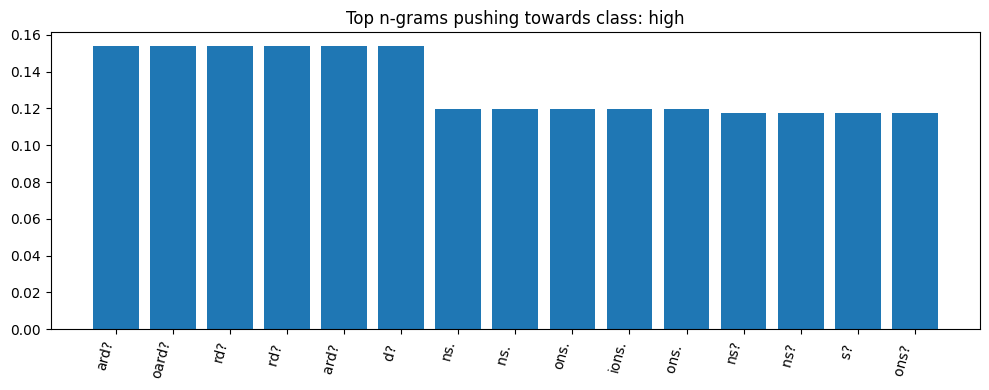

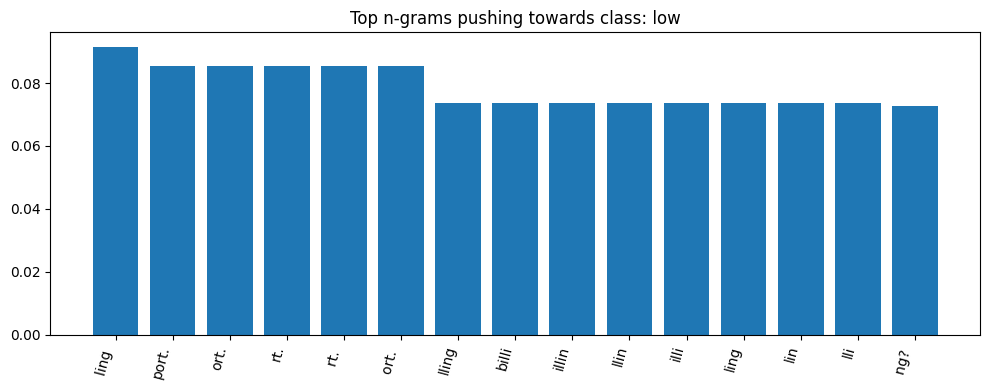

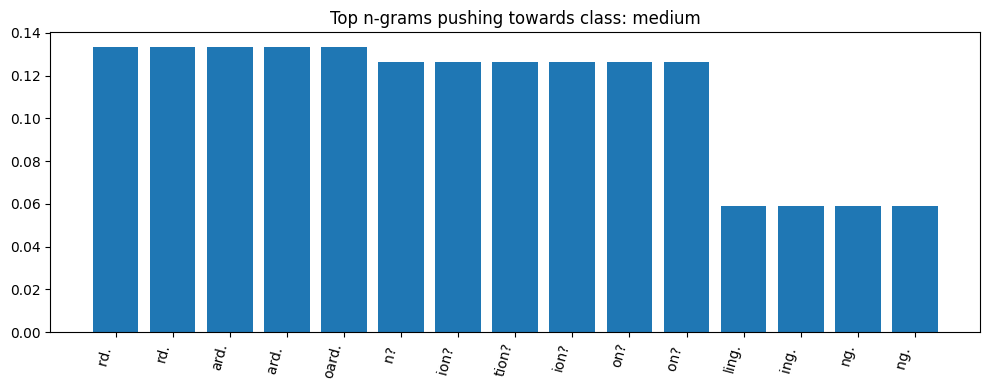

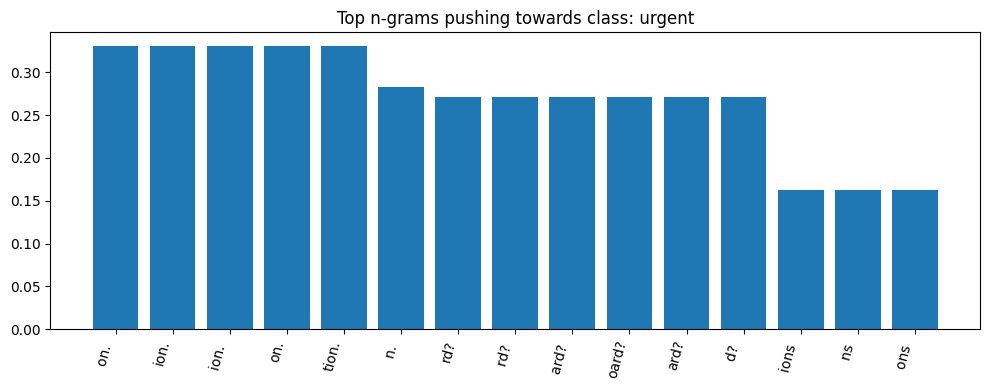

In [138]:

feature_names = vectorizer.get_feature_names_out()
classes = list(sgd.classes_)

def top_features_for_class(model, class_name: str, top_n: int = 20):
    k = classes.index(class_name)
    coef = model.coef_[k]
    top_idx = np.argsort(-coef)[:top_n]
    return [(feature_names[i], float(coef[i])) for i in top_idx]

for c in classes:
    feats = top_features_for_class(sgd, c, top_n=15)
    df_feats = pd.DataFrame(feats, columns=["ngram", "weight"])
    plt.figure(figsize=(10,4))
    plt.bar(df_feats["ngram"], df_feats["weight"])
    plt.title(f"Top n-grams pushing towards class: {c}")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()


In [139]:

def explain_linear_local(model, vectorizer, text_masked: str, class_name: str, top_n: int = 15):
    X = vectorizer.transform([text_masked])
    if X.nnz == 0:
        return []
    k = classes.index(class_name)
    coef = model.coef_[k]
    idx = X.indices
    vals = X.data * coef[idx]
    order = np.argsort(-vals)
    out = []
    for j in order:
        if vals[j] <= 0:
            continue
        out.append((feature_names[idx[j]], float(vals[j])))
        if len(out) >= top_n:
            break
    return out

sample_text = df["text_masked"].iloc[100]
proba = sgd.predict_proba(vectorizer.transform([sample_text]))[0]
pred = sgd.classes_[int(np.argmax(proba))]
conf = float(np.max(proba))
print("Sample:", sample_text)
print("Predicted:", pred, "| confidence:", round(conf, 3))

local_feats = explain_linear_local(sgd, vectorizer, sample_text, pred, top_n=12)
display(pd.DataFrame(local_feats, columns=["feature", "contribution"]))


Sample: My account was locked after multiple failed login attempts.
Predicted: low | confidence: 0.335


,feature,contribution
0,le,0.001222
1,iled,0.001038
2,fail,0.001038
3,fai,0.001038
4,multi,0.001038
5,empts,0.001038
6,empt,0.001038
7,emp,0.001038
8,ock,0.001038
9,ocke,0.001038



## 11) Retrieval похожих тикетов (RAG-like) без дублей


In [146]:
import pandas as pd

TEXT_COL = "initial_message"   # <-- поменяй если у тебя другое имя

# 1) сколько всего строк и сколько уникальных текстов
n_total = len(df)
n_unique = df[TEXT_COL].nunique(dropna=False)

# 2) сколько строк являются "дубликатами" по тексту (включая все повторения)
dup_mask = df.duplicated(subset=[TEXT_COL], keep=False)
n_dup_rows = int(dup_mask.sum())

# 3) сколько "лишних" строк сверх уникальных (т.е. сколько строк можно убрать дедупом)
n_extra = n_total - df.drop_duplicates(subset=[TEXT_COL]).shape[0]

print("=== Duplicates by text ===")
print("Total rows:", n_total)
print("Unique texts:", n_unique)
print("Duplicate rows (all rows that have a duplicate):", n_dup_rows, f"({n_dup_rows/n_total:.2%})")
print("Extra rows removable by drop_duplicates:", n_extra, f"({n_extra/n_total:.2%})")

# 4) топ-20 самых частых текстов
top = df[TEXT_COL].value_counts(dropna=False).head(20).reset_index()
top.columns = [TEXT_COL, "count"]
display(top)

# 5) посмотреть примеры: возьми один самый частый текст
most_common_text = top.iloc[0][TEXT_COL]
print("\n--- Most common text example ---")
print(most_common_text)

=== Duplicates by text ===
Total rows: 100000
Unique texts: 96
Duplicate rows (all rows that have a duplicate): 100000 (100.00%)
Extra rows removable by drop_duplicates: 99904 (99.90%)


,initial_message,count
0,"Something seems off, can you please check my w...",4279
1,I downgraded my plan but I am still being bill...,4263
2,My 2FA code is not working when I try to sign in.,4255
3,We need details about your data encryption and...,4202
4,My account was locked after multiple failed lo...,4200
5,I cannot log in; the system says my password i...,4154
6,I have a general question about my account.,4152
7,Overall performance has degraded in the last f...,4121
8,I noticed a suspicious login on my account.,4097
9,I was charged twice for my subscription this m...,4066



--- Most common text example ---
Something seems off, can you please check my workspace?


In [140]:

tmpl = df[["text_masked", "priority", "issue_type", "product_area"]].copy()
grouped = tmpl.groupby("text_masked")

rows = []
for text_key, g in grouped:
    if not str(text_key).strip():
        continue
    dist = g["priority"].value_counts(normalize=True).to_dict()
    rows.append({
        "template_text": str(text_key),
        "count": int(len(g)),
        "priority_mode": g["priority"].value_counts().idxmax(),
        "priority_dist": {k: float(v) for k,v in dist.items()},
        "issue_type_mode": g["issue_type"].value_counts().idxmax(),
        "product_area_mode": g["product_area"].value_counts().idxmax(),
    })

templates_df = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
print("Unique templates:", len(templates_df))
display(templates_df.head(5))


Unique templates: 96


,template_text,count,priority_mode,priority_dist,issue_type_mode,product_area_mode
0,"Something seems off, can you please check my w...",4279,low,"{'low': 0.4136480486094882, 'medium': 0.341668...",other,data_export
1,I downgraded my plan but I am still being bill...,4263,low,"{'low': 0.40464461646727656, 'medium': 0.36124...",billing_problem,api_integration
2,My 2FA code is not working when I try to sign in.,4255,low,"{'low': 0.3981198589894242, 'medium': 0.350646...",account_access,billing
3,We need details about your data encryption and...,4202,low,"{'low': 0.4007615421227987, 'medium': 0.348643...",security_concern,analytics_dashboard
4,My account was locked after multiple failed lo...,4200,low,"{'low': 0.39666666666666667, 'medium': 0.34595...",account_access,login_auth


In [141]:

template_matrix = vectorizer.transform(templates_df["template_text"])

def retrieve(query: str, top_k: int = 5):
    q = mask_pii(query)
    qv = vectorizer.transform([q])
    sims = cosine_similarity(qv, template_matrix).ravel()
    top_idx = np.argsort(-sims)[:top_k]
    out = templates_df.iloc[top_idx].copy()
    out["similarity"] = sims[top_idx]
    out["priority_dist_str"] = out["priority_dist"].apply(
        lambda d: ", ".join([f"{k}:{d.get(k,0):.2f}" for k in sorted(d.keys())])
    )
    return out[["similarity","count","priority_mode","priority_dist_str","issue_type_mode","product_area_mode","template_text"]]

retrieve("I noticed a suspicious login on my account.", top_k=5)


,similarity,count,priority_mode,priority_dist_str,issue_type_mode,product_area_mode,template_text
8,1.000000,4097,low,"high:0.19, low:0.40, medium:0.36, urgent:0.05",security_concern,notifications,I noticed a suspicious login on my account.
6,0.224247,4152,low,"high:0.21, low:0.40, medium:0.35, urgent:0.05",other,analytics_dashboard,I have a general question about my account.
4,0.184657,4200,low,"high:0.20, low:0.40, medium:0.35, urgent:0.06",account_access,login_auth,My account was locked after multiple failed lo...
52,0.107426,600,low,"high:0.21, low:0.38, medium:0.37, urgent:0.05",bug,login_auth,The login auth feature is not saving my changes.
26,0.107378,624,low,"high:0.20, low:0.38, medium:0.37, urgent:0.05",how_to,login_auth,I need help setting up login auth for my team.



## 12) Policy layer (hard rules) — фикс для критичных тикетов


In [142]:

ALLOWED_PRIORITIES = ["low","medium","high","urgent"]
PRIORITY_RANK = {"low":0,"medium":1,"high":2,"urgent":3}

SECURITY_PATTERNS = [
    r"\bstolen\b", r"\btheft\b", r"\bfraud\b", r"\bscam\b", r"\bhacked\b",
    r"\bbreach\b", r"\bcompromised\b", r"\bunauthorized\b", r"\bsuspicious login\b",
    r"\bphishing\b", r"\bmalware\b", r"\bransomware\b",
    # RU
    r"\bукрал[аои]?\b", r"\bкраж", r"\bмошенн", r"\bвзлом", r"\bутеч", r"\bфишинг\b",
    r"\bнесанкцион", r"\bподозрительн", r"\bсписал[иа]\b",
]
OUTAGE_PATTERNS = [
    r"\bdown\b", r"\boutage\b", r"\bunavailable\b", r"\boffline\b",
    r"\b503\b", r"\b500\b", r"\bservice unavailable\b", r"\bprod\b", r"\bproduction\b",
    # RU
    r"\bне работает\b", r"\bнедоступ", r"\bупал[аои]?\b", r"\bошибка 500\b", r"\bошибка 503\b",
    r"\bпрод\b", r"\bпродакшн\b",
]
URGENT_WORDS = [r"\burgent\b", r"\basap\b", r"\bimmediately\b", r"\bсрочно\b", r"\bнемедленно\b"]
MONEY_PATTERNS = [
    r"\$\s*\d[\d,.\s]*", r"\b\d[\d,.\s]*\s*(usd|dollars|eur|€|руб|rub|рублей|₽)\b",
    r"\b\d+\s*(k|тыс)\b",
]

def _has_any(patterns, text_lower):
    return any(re.search(p, text_lower) for p in patterns)

def policy_min_priority(text: str):
    t = (text or "").lower()
    if _has_any(SECURITY_PATTERNS, t):
        if _has_any(MONEY_PATTERNS, t):
            return "urgent"
        return "urgent"
    if _has_any(OUTAGE_PATTERNS, t):
        return "high"
    if _has_any(URGENT_WORDS, t):
        return "high"
    return None

def apply_floor(priority: str, floor):
    if floor is None:
        return priority
    return floor if PRIORITY_RANK[floor] > PRIORITY_RANK[priority] else priority

tests = [
    "My account was hacked and money was stolen. Please help!",
    "Service is down for all users. 503 errors on prod.",
    "у меня украли 100к долларов что делать",
    "не работает продакшн, ошибка 500, срочно",
]

for t in tests:
    tm = mask_pii(t)
    proba = sgd.predict_proba(vectorizer.transform([tm]))[0]
    ml = sgd.classes_[int(np.argmax(proba))]
    conf = float(np.max(proba))
    floor = policy_min_priority(tm)
    final = apply_floor(ml, floor)
    print("\nTicket:", t)
    print("ML:", ml, "| conf:", round(conf,3), "| Policy floor:", floor, "| Final:", final)
    tm = mask_pii(t)
    X = vectorizer.transform([tm])
    print("NNZ:", X.nnz)
    print("TOP features:", X.indices[:20])  # просто чтобы видеть что вообще есть
    print("PROBA:", dict(zip(sgd.classes_, sgd.predict_proba(X)[0])))



Ticket: My account was hacked and money was stolen. Please help!
ML: low | conf: 0.299 | Policy floor: urgent | Final: urgent
NNZ: 67
TOP features: [  7   8   9  22  26  27 133 138 139 140 186 191 198 199 233 236 237 270
 319 320]
PROBA: {np.str_('high'): np.float64(0.23077246609995067), np.str_('low'): np.float64(0.2994758998004887), np.str_('medium'): np.float64(0.24899815675992928), np.str_('urgent'): np.float64(0.2207534773396313)}

Ticket: Service is down for all users. 503 errors on prod.
ML: low | conf: 0.29 | Policy floor: high | Final: high
NNZ: 42
TOP features: [ 94  95  96 100 101 102 118 119 120 163 164 210 211 238 239 240 251 382
 383 508]
PROBA: {np.str_('high'): np.float64(0.24167339753141637), np.str_('low'): np.float64(0.2900889082609435), np.str_('medium'): np.float64(0.25920144084015767), np.str_('urgent'): np.float64(0.2090362533674825)}

Ticket: у меня украли 100к долларов что делать
ML: medium | conf: 0.275 | Policy floor: urgent | Final: urgent
NNZ: 0
TOP featur


## 13) GPT (Transformer) — объяснение и fallback

Ниже код, который:
- подключается к OpenAI через LangChain
- возвращает JSON-объяснение


In [143]:

# Run locally: set OPENAI_API_KEY in ../.env (see .env.example) and install requirements.txt
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
assert OPENAI_API_KEY, "Set OPENAI_API_KEY in ../.env (see .env.example)"

llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    temperature=float(os.getenv("OPENAI_TEMPERATURE", "0.0")),
)
print("LLM:", llm.model)

PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "Ты — AI ассистент для triage IT тикетов. "
     "Выводи ТОЛЬКО валидный JSON (один объект). "
     "Без markdown, без ``` и без любого текста вне JSON. "
     "Не раскрывай PII."),
    ("human",
     '''Ticket (masked):
{ticket}

ML:
- ml_priority: {ml_priority}
- ml_confidence: {ml_confidence}
- ml_proba: {ml_proba}

Policy:
- policy_floor: {policy_floor}
- final_priority: {final_priority}

Return JSON:
{{
  "summary": string,
  "why_this_priority": [string, ...],
  "immediate_actions": [string, ...],
  "clarifying_questions": [string, ...],
  "risks": [string, ...],
  "suggested_priority": "low"|"medium"|"high"|"urgent"
}}
''')
])

def safe_parse_json(text: str):
    try:
        return json.loads(text)
    except Exception:
        m = re.search(r"\{.*\}", text, re.DOTALL)
        if not m:
            return {"raw": text}
        return json.loads(m.group(0))

def gpt_explain(ticket_text: str):
    tm = mask_pii(ticket_text)
    proba = sgd.predict_proba(vectorizer.transform([tm]))[0]
    ml = sgd.classes_[int(np.argmax(proba))]
    conf = float(np.max(proba))
    floor = policy_min_priority(tm)
    final = apply_floor(ml, floor)

    msg = PROMPT.format_messages(
        ticket=tm,
        ml_priority=ml,
        ml_confidence=f"{conf:.3f}",
        ml_proba=json.dumps({c: float(p) for c,p in zip(sgd.classes_, proba)}, ensure_ascii=False),
        policy_floor=floor or "none",
        final_priority=final,
    )
    resp = llm.invoke(msg)
    return safe_parse_json(resp.content)

gpt_explain("I can't reset my password")


LLM: gpt-4o-mini


{'summary': 'User is unable to reset their password.',
 'why_this_priority': ['Password reset issues can hinder user access to systems.',
  'The user may be unable to perform critical tasks without access.'],
 'immediate_actions': ["Verify the user's identity through security questions or alternative methods.",
  'Provide instructions for password reset or assist in the process.'],
 'clarifying_questions': ['What error message do you receive when attempting to reset your password?',
  "Have you tried using the 'Forgot Password' feature?"],
 'risks': ['User may be locked out of their account, affecting productivity.',
  'Potential security risks if the password reset process is not handled properly.'],
 'suggested_priority': 'medium'}


### Мини-эксперимент: GPT извлекает “severity cues” (ключевые фразы)

Чтобы “использовать transformer для понимания важности слов”, можно попросить GPT выделить cues,
а затем визуализировать их частотность.

⚠️ Делаем на небольшом сэмпле (например, 30 тикетов), чтобы не тратить много токенов.


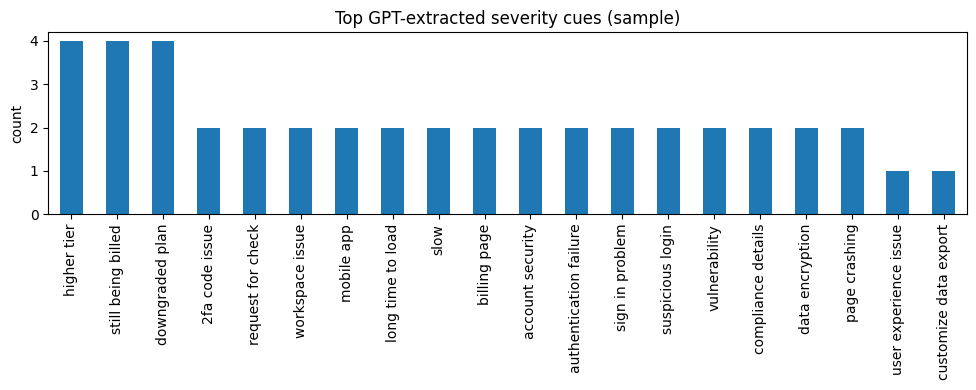

medium    23
high       6
low        1
Name: count, dtype: int64

In [144]:

CUE_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "Ты анализируешь тикет и возвращаешь ТОЛЬКО JSON. Не раскрывай PII."),
    ("human",
     '''Ticket (masked):
{ticket}

Return JSON:
{{
  "cues": [string, ...],
  "suggested_priority": "low"|"medium"|"high"|"urgent"
}}
''')
])

def extract_cues(ticket_text: str):
    msg = CUE_PROMPT.format_messages(ticket=mask_pii(ticket_text))
    r = llm.invoke(msg)
    return safe_parse_json(r.content)

sample_n = 30
sample_tickets = df["initial_message"].dropna().sample(sample_n, random_state=42).tolist()

cues = []
suggested = []
for t in sample_tickets:
    out = extract_cues(t)
    cues.extend(out.get("cues", []))
    suggested.append(out.get("suggested_priority"))

cues_series = pd.Series([str(c).lower().strip() for c in cues if str(c).strip()])
top_cues = cues_series.value_counts().head(20)

plt.figure(figsize=(10,4))
top_cues.plot(kind="bar")
plt.title("Top GPT-extracted severity cues (sample)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

pd.Series(suggested).value_counts()



## 14) Save artifacts (для Streamlit)

Streamlit `app.py` читает артефакты из `../artifacts/`.


In [145]:

# Choose model to ship
MODEL_TO_SHIP = sgd

retrieval_bundle = {
    "templates_df": templates_df,
    "template_matrix": template_matrix,
}

metrics = {
    "split": "time_based_80_20",
    "model": "SGDClassifier(log_loss, class_weight=balanced)",
    "accuracy": float(accuracy_score(y_test, pred_sgd)),
    "macro_f1": float(f1_score(y_test, pred_sgd, average="macro")),
    "prediction_distribution_test": pd.Series(pred_sgd).value_counts(normalize=True).to_dict(),
    "label_distribution_train": y_train.value_counts(normalize=True).to_dict(),
    "label_distribution_test": y_test.value_counts(normalize=True).to_dict(),
    "classification_report": classification_report(y_test, pred_sgd, output_dict=True),
}

joblib.dump(vectorizer, ARTIFACTS_DIR / "priority_vectorizer.joblib")
joblib.dump(MODEL_TO_SHIP, ARTIFACTS_DIR / "priority_model.joblib")
joblib.dump(retrieval_bundle, ARTIFACTS_DIR / "retrieval_bundle.joblib")
with open(ARTIFACTS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Saved artifacts to:", ARTIFACTS_DIR)


Saved artifacts to: /Users/artemkim/Downloads/it_ticket_triage_project_v3/artifacts


Exception ignored in: <function ResourceTracker.__del__ at 0x10306dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102f11bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102b11bc0>
Traceback (most recent call last


## 15) Как запустить приложение

После сохранения артефактов:

```bash
cd <project_root>
streamlit run app.py
```

В UI:
- вводишь текст тикета
- видишь `final_priority`, объяснение GPT, похожие тикеты **без дублей**
- можешь сохранить feedback в `data/feedback.csv`
